# Heart Disease Prediction, Machine Learning Project

**Course:** Machine Learning (AIN-B), Summer Semester 2026 (Prof. Markus Mayer)
**Group 31:** Parth Navadiya, Narender Kumar (AIN-B, 8th semester)

### Dataset
- **Source:** Kaggle, *Heart Disease Health Indicators Dataset* (Alex Teboul),
  derived from the CDC **BRFSS 2015** telephone survey.
- **License:** CC0 (Public Domain).
- **Size:** 253,680 rows x 22 columns, all numeric, no missing values.
- **Target:** `HeartDiseaseorAttack` (0 = no, 1 = yes).

### Method
A clean train/test split and **k-Nearest-Neighbours (kNN)** as our classifier, with
**hyperparameter optimization** (choosing the number of neighbours *k* by cross-validation).
Because this is a *classification* problem with imbalanced classes, we use the standard
classification **error measures** (the 0-1 classification error and the **class-wise averaged
classification rate**, plus sensitivity/specificity) together with **confusion matrices**.


## Problem formulation

**In words.** From a person's cheap, self-reported health and lifestyle answers, we want to
predict whether they have ever had heart disease or a heart attack, so the model could act as an
early-screening flag.


## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

# Classifier for this project: k-Nearest-Neighbours. LinearDiscriminantAnalysis is
# used only as a fast inner estimator for forward feature selection (Section 10).
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
RANDOM_STATE = 42          # fixed seed -> reproducible results
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load and inspect the data

First we check the shape, look for missing values and duplicates, and see how many distinct
values each column has.

In [4]:
df = pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")
print("Shape:", df.shape)
df.head()

Shape: (253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
print("Missing values total :", df.isnull().sum().sum())
print("Duplicate rows       :", df.duplicated().sum())
print("\nUnique values per column:")
print(df.nunique())

Missing values total : 0
Duplicate rows       : 23899

Unique values per column:
HeartDiseaseorAttack     2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
Diabetes                 3
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64


## 3. Class distribution, how many samples per class?

The first thing to check is how many people fall in each class of the target. This decides which
error measures make sense.

Samples per class:


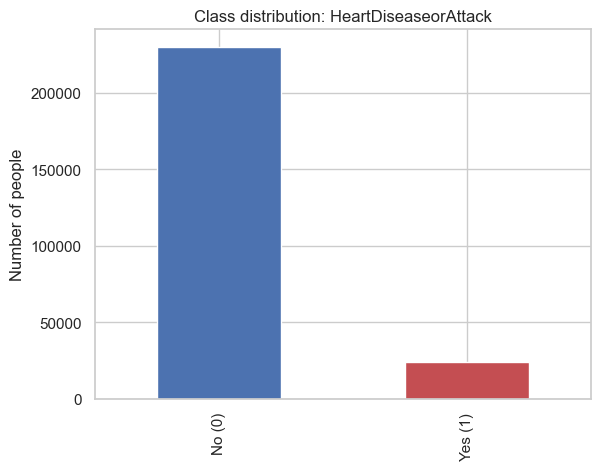

In [6]:
counts = df["HeartDiseaseorAttack"].value_counts().sort_index()
counts.index = ["No (0)", "Yes (1)"]
percent = (counts / counts.sum() * 100).round(1)
print("Samples per class:")
ax = counts.plot(kind="bar", color=["#4c72b0", "#c44e52"] )
ax.set_title("Class distribution: HeartDiseaseorAttack")
ax.set_ylabel("Number of people")
plt.show()

The Dataset is imbalanced.
Only about **10.3 %** are in the positive ("Yes") class vs. **89.7 %** "No", roughly a **10 : 1**
imbalance. A lazy model that always predicts "No" would already reach about 90.6 % accuracy while
finding **zero** sick people.

## 4. Data cleaning

No values are missing, so the only step is **removing exact duplicate rows**. These are repeated
anonymous survey records; keeping them could place the *same* row in both train and test data
and secretly connect the two sets, which would invalidate the evaluation.

In [7]:
print("Missing values total :", df.isnull().sum().sum())

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df):,} duplicate rows. New shape: {df.shape}")

Missing values total : 0
Removed 23,899 duplicate rows. New shape: (229781, 22)


## 5. Discovering the data with graphs

Before modelling we visualise the data, using **histograms**
(distribution of each feature) and a **scatter plot** to understand the data.

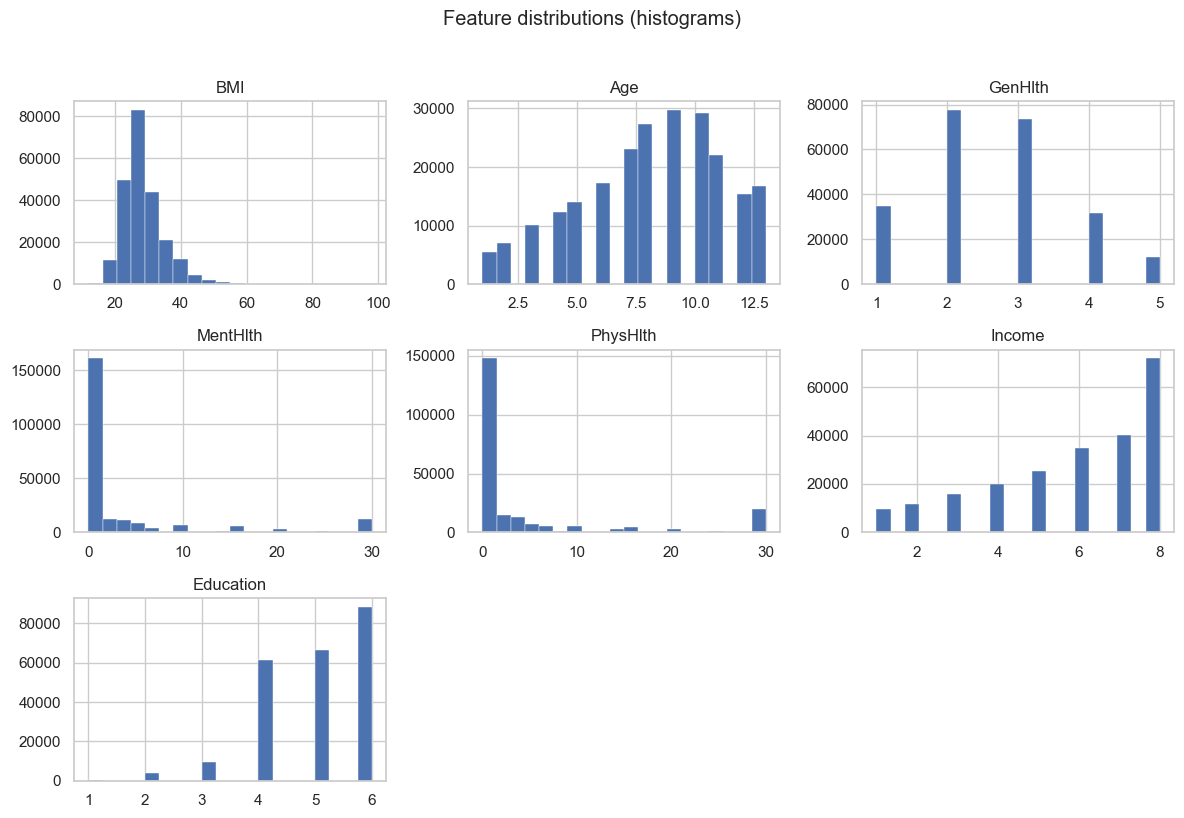

In [8]:
# Histograms: distribution of the more numeric / ordinal features
# (binary 0/1 flags like Smoker are excluded - a histogram of a yes/no column is just two bars)
num_cols = ["BMI", "Age", "GenHlth", "MentHlth", "PhysHlth", "Income", "Education"]
df[num_cols].hist(bins=20, figsize=(12, 8), color="#4c72b0", linewidth=0.3)
plt.suptitle("Feature distributions (histograms)", y=1.02)
plt.tight_layout()
plt.show()

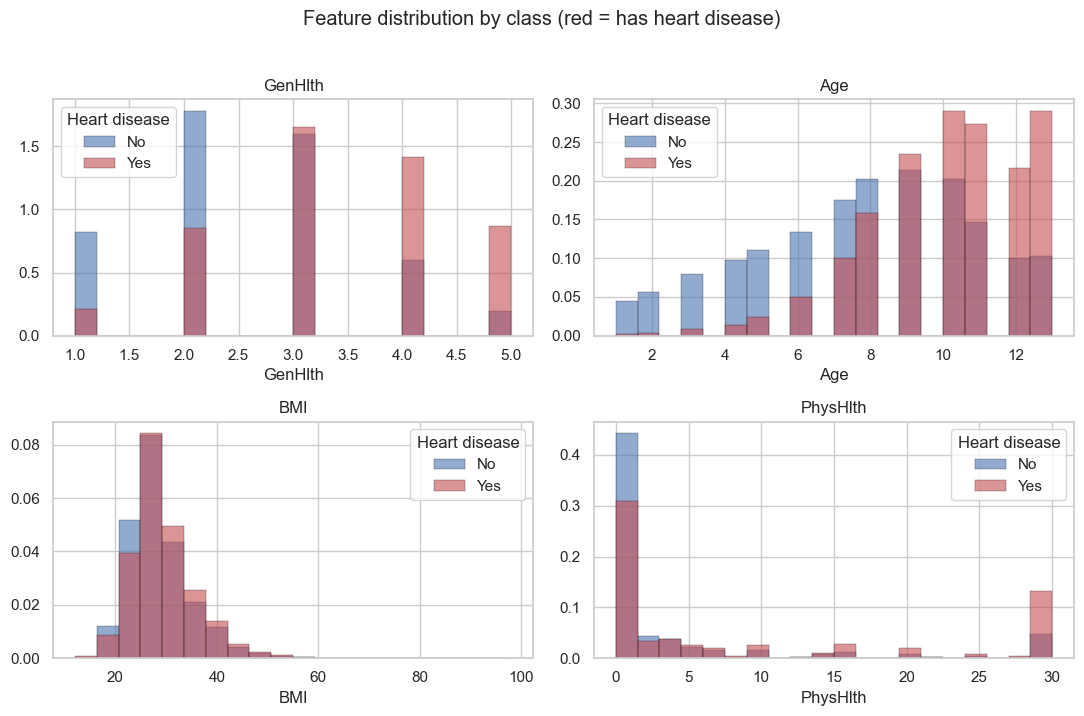

In [9]:
# Class-conditional histograms: does the feature look different for sick vs healthy people?
# density=True so the shapes are comparable despite the 10:1 imbalance.
key_feats = ["GenHlth", "Age", "BMI", "PhysHlth"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, f in zip(axes.ravel(), key_feats):
    for cls, color, label in [(0, "#4c72b0", "No"), (1, "#c44e52", "Yes")]:
        ax.hist(df.loc[df["HeartDiseaseorAttack"] == cls, f], bins=20, density=True,
                alpha=0.6, color=color, label=label, edgecolor="black", linewidth=0.3)
    ax.set_title(f); ax.set_xlabel(f); ax.legend(title="Heart disease")
plt.suptitle("Feature distribution by class (red = has heart disease)", y=1.02)
plt.tight_layout()
plt.show()

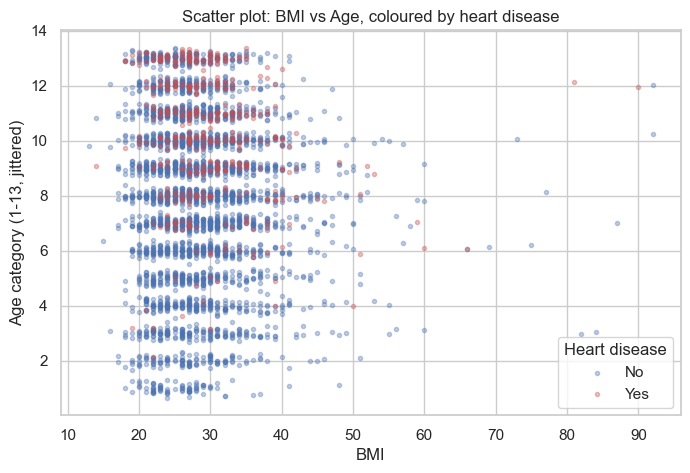

In [10]:
# Scatter plot: two continuous features, coloured by class (Age is bucketed, so we add jitter).
samp = df.sample(4000, random_state=RANDOM_STATE)
plt.figure(figsize=(8, 5))
for cls, color, label in [(0, "#4c72b0", "No"), (1, "#c44e52", "Yes")]:
    s = samp[samp["HeartDiseaseorAttack"] == cls]
    jitter = np.random.RandomState(cls).normal(0, 0.15, len(s))
    plt.scatter(s["BMI"], s["Age"] + jitter, s=9, alpha=0.35, color=color, label=label)
plt.xlabel("BMI"); plt.ylabel("Age category (1-13, jittered)")
plt.title("Scatter plot: BMI vs Age, coloured by heart disease")
plt.legend(title="Heart disease")
plt.show()

### Why only BMI vs Age gets a scatter plot (demonstration)

To *see* the reason, we draw four scatter plots of different feature types. A scatter is only
useful when **both** axes spread across many values; binary 0/1 flags and the spiked 0-30 counts
collapse into stripes or blobs that tell us nothing.

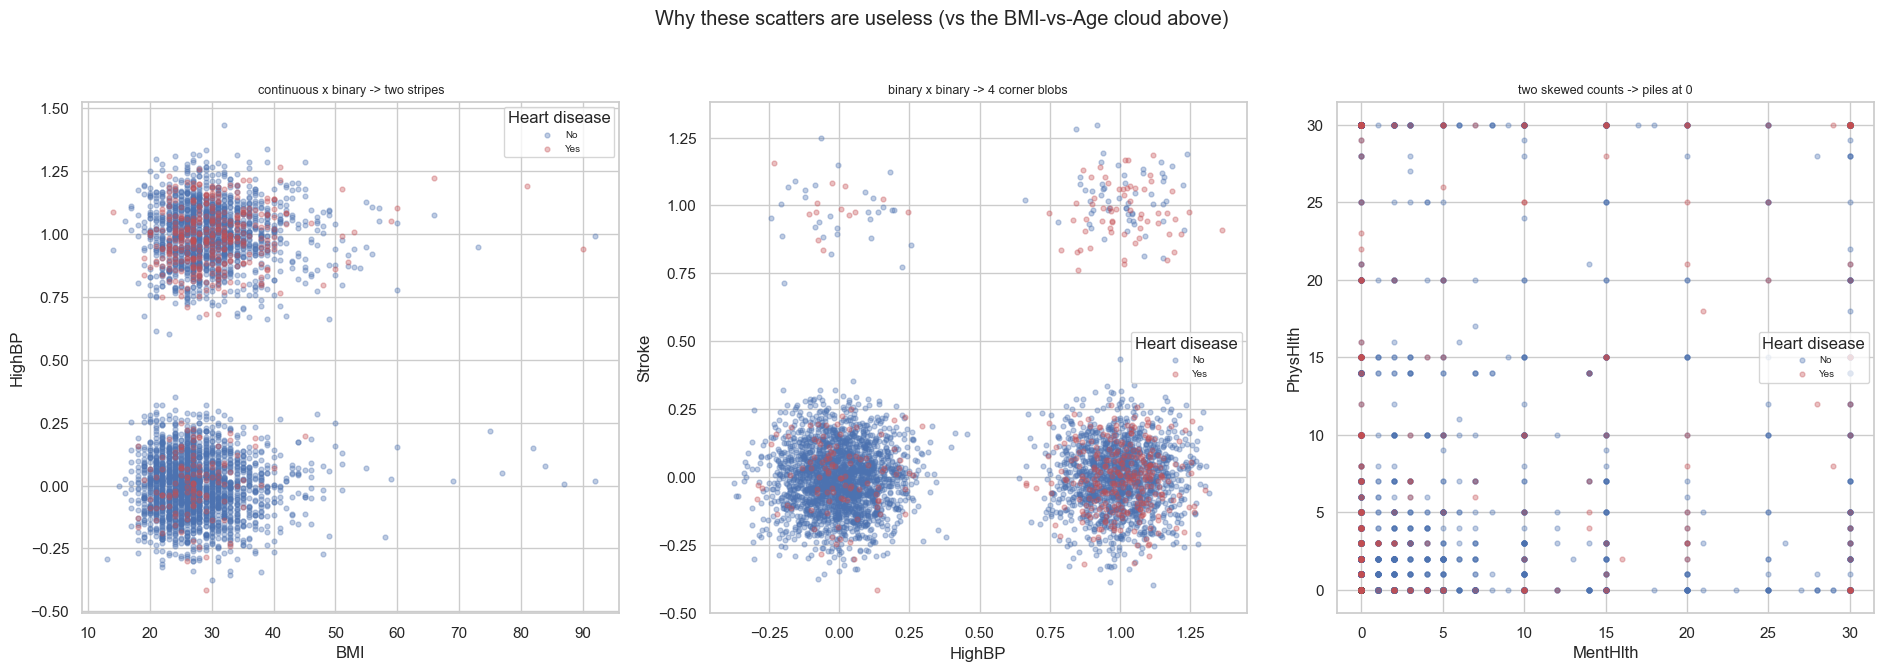

In [11]:
# Demonstration: the BMI vs Age scatter above is the ONLY useful one. Here are the 3 cases
# where a scatter fails, because at least one axis is binary or spiked (no real spread).
samp = df.sample(4000, random_state=RANDOM_STATE)
pairs = [
    ("BMI", "HighBP",        "continuous x binary -> two stripes"),
    ("HighBP", "Stroke",     "binary x binary -> 4 corner blobs"),
    ("MentHlth", "PhysHlth",  "two skewed counts -> piles at 0"),
]
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (fx, fy, note) in zip(axes, pairs):
    for cls, color, label in [(0, "#4c72b0", "No"), (1, "#c44e52", "Yes")]:
        s = samp[samp["HeartDiseaseorAttack"] == cls]
        # add jitter only to low-cardinality (bucketed/binary) axes so points don't stack
        jx = np.random.RandomState(cls).normal(0, 0.12, len(s)) if df[fx].nunique() < 15 else 0
        jy = np.random.RandomState(cls + 10).normal(0, 0.12, len(s)) if df[fy].nunique() < 15 else 0
        ax.scatter(s[fx] + jx, s[fy] + jy, s=12, alpha=0.35, color=color, label=label)
    ax.set_xlabel(fx); ax.set_ylabel(fy); ax.set_title(note, fontsize=9)
    ax.legend(title="Heart disease", fontsize=7)
plt.suptitle("Why these scatters are useless (vs the BMI-vs-Age cloud above)", y=1.03)
plt.tight_layout(); plt.show()


## 6. Feature relationships, which features relate to the target?

A numeric view of the same question: how strongly each feature correlates with the target, and
how features relate to each other (redundancy).

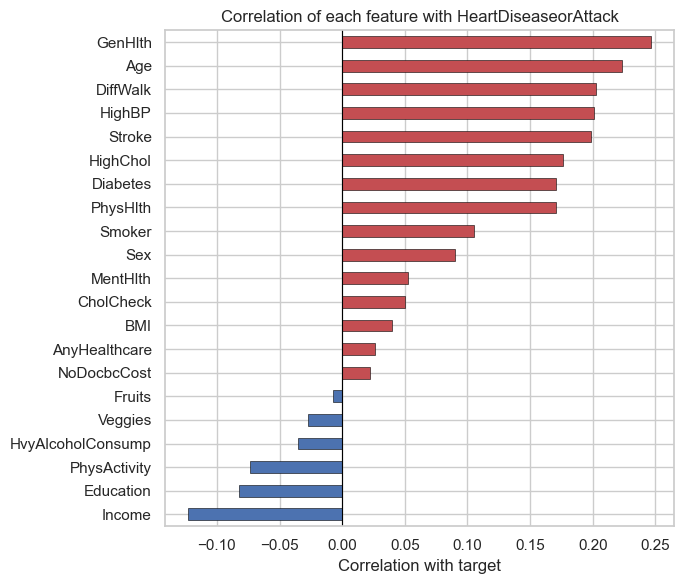

Strongest relations to the target:
GenHlth     0.246
Age         0.224
DiffWalk    0.203
HighBP      0.201
Stroke      0.199
HighChol    0.176
Diabetes    0.171
Name: HeartDiseaseorAttack, dtype: float64


In [12]:
corr_target = (df.corr()["HeartDiseaseorAttack"].drop("HeartDiseaseorAttack").sort_values())
ax = corr_target.plot(kind="barh", figsize=(7, 6),
                      color=["#c44e52" if v > 0 else "#4c72b0" for v in corr_target],
                      edgecolor="black", linewidth=0.4)
ax.set_title("Correlation of each feature with HeartDiseaseorAttack")
ax.set_xlabel("Correlation with target"); ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout(); plt.show()
print("Strongest relations to the target:")
print(corr_target.abs().sort_values(ascending=False).head(7).round(3))

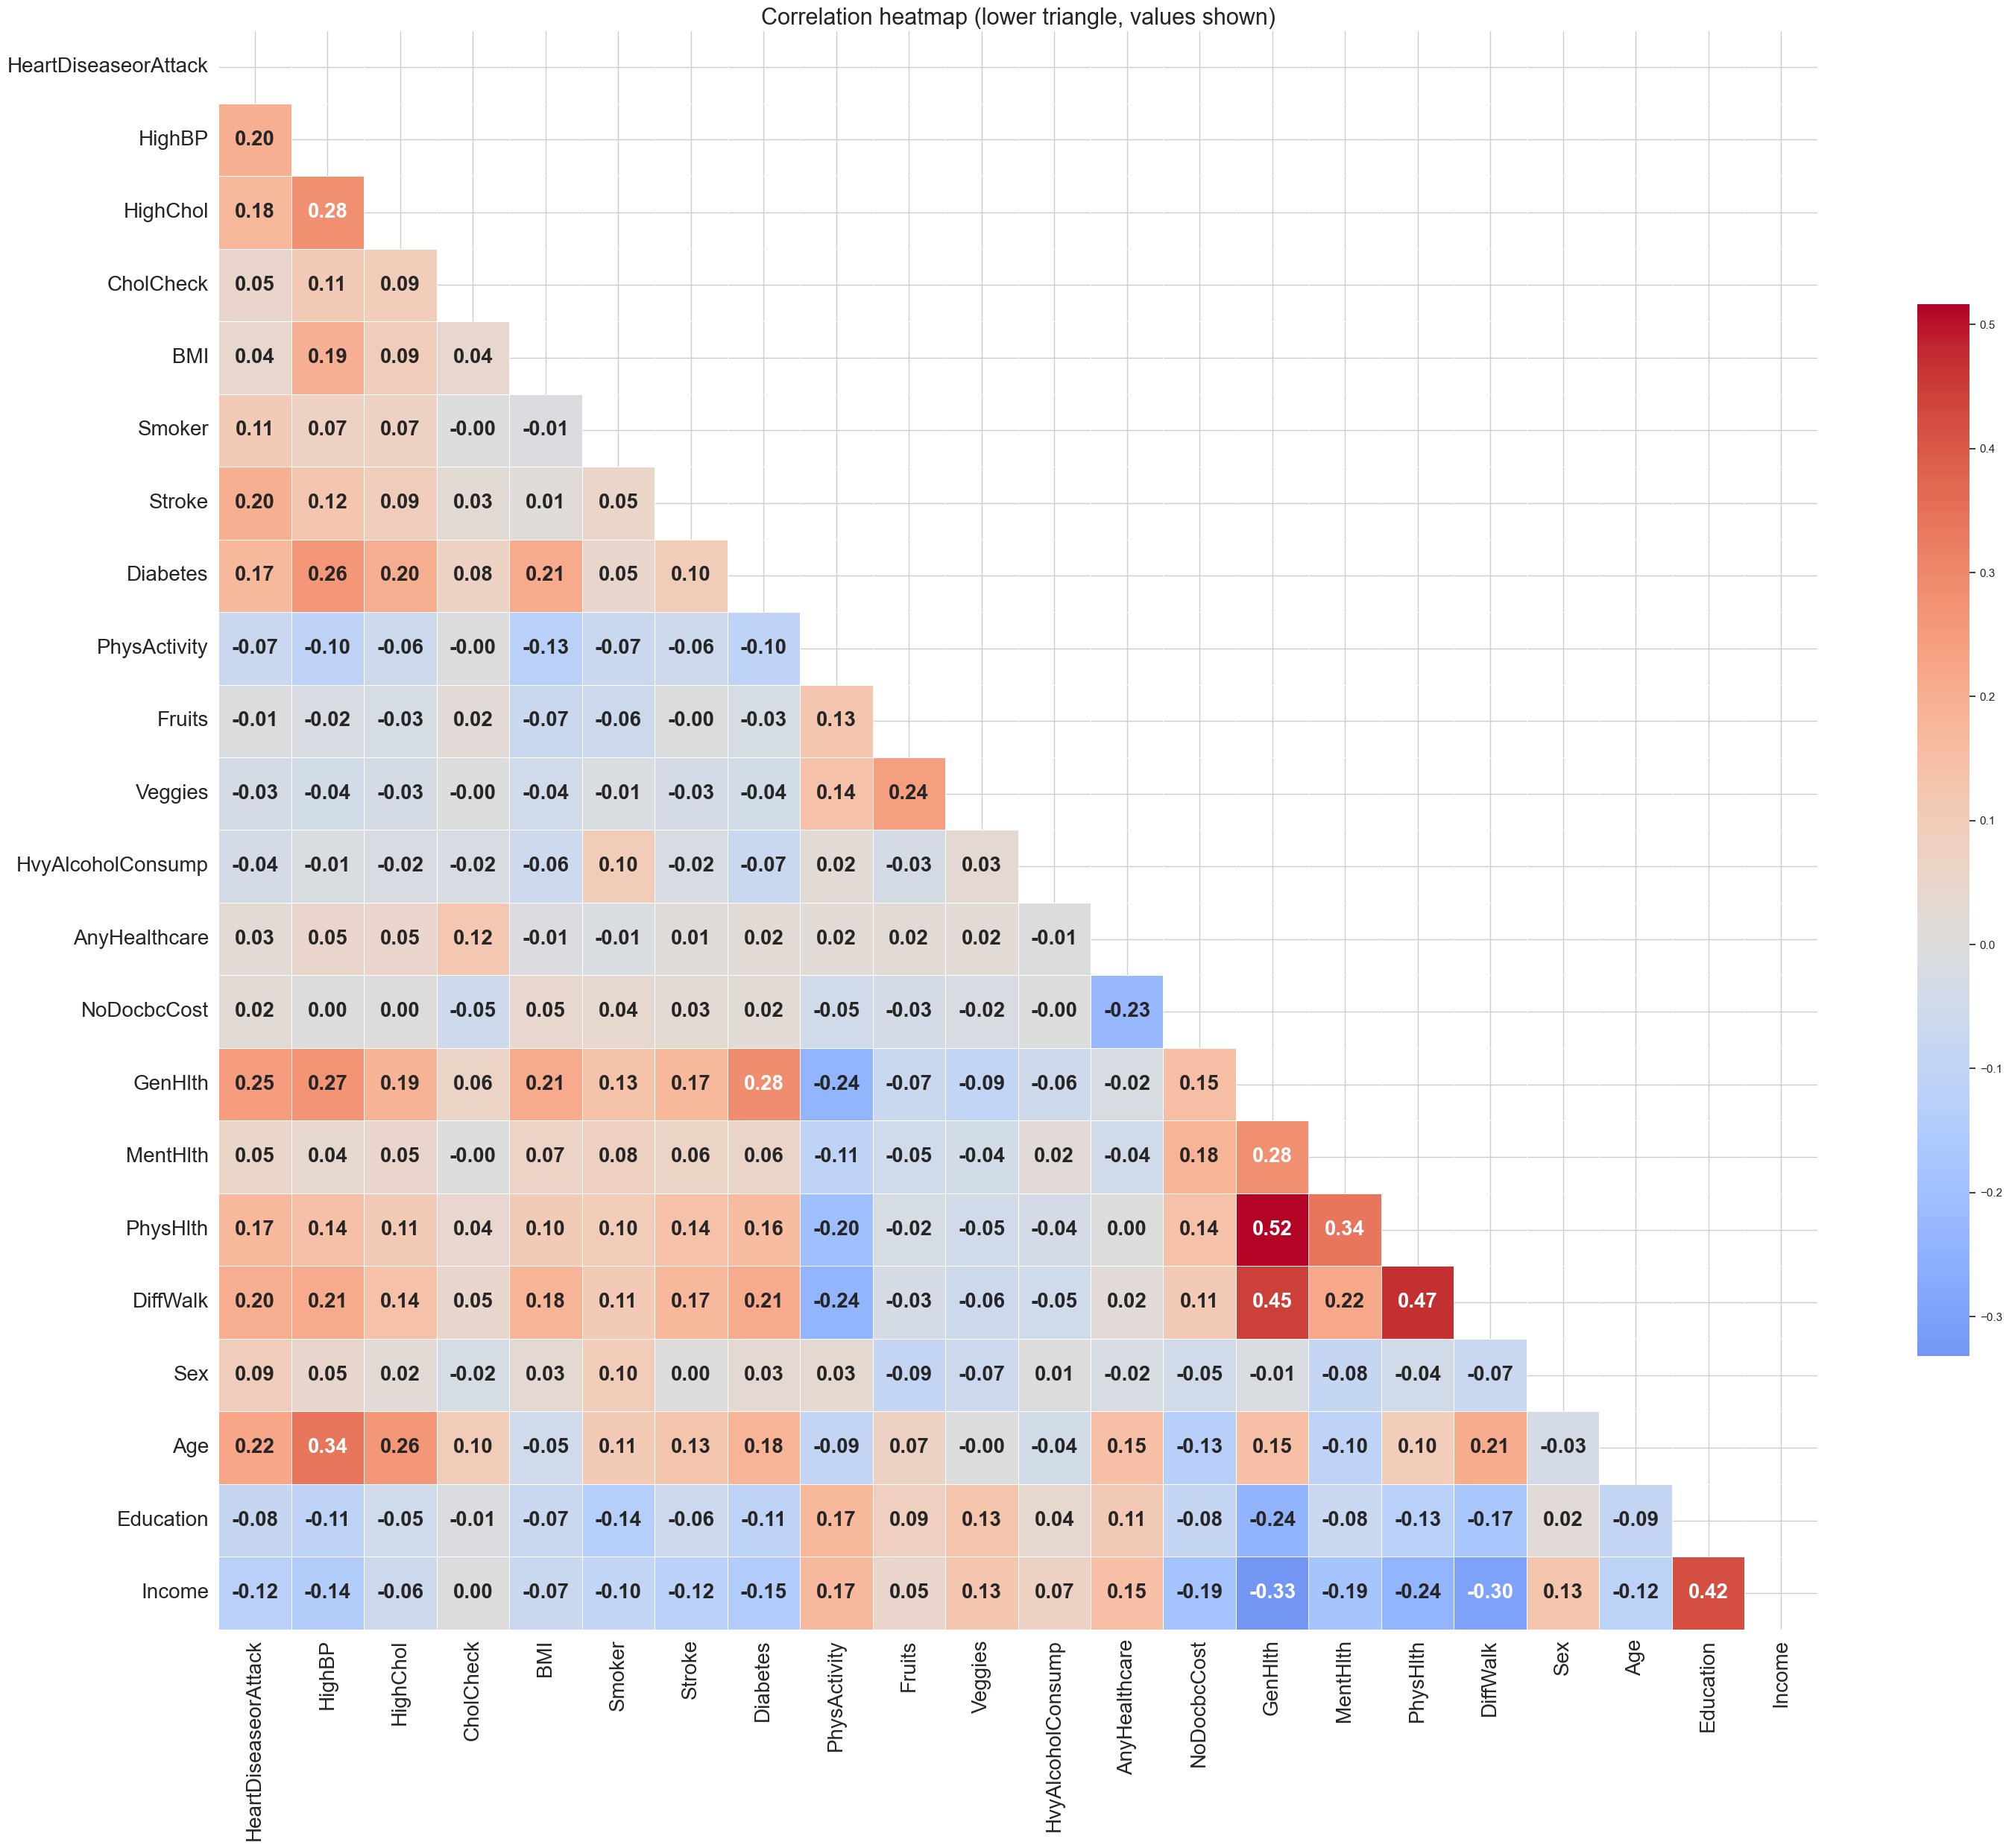

In [13]:
# Lower-triangle correlation heatmap (upper half is a duplicate mirror, so we hide it).
import numpy as np
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))      # hide the duplicate upper triangle + diagonal
plt.figure(figsize=(30, 26))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 20, "weight": "bold"},
            linewidths=0.4, cbar_kws={"shrink": 0.6})
plt.title("Correlation heatmap (lower triangle, values shown)", fontsize=22)
plt.xticks(fontsize=20); plt.yticks(fontsize=20)
plt.tight_layout(); plt.show()


**Reading it:** the strongest correlates of heart disease are `GenHlth`, `Age`, `DiffWalk`,
`HighBP`, `Stroke`, `HighChol` and `Diabetes`, the same features the histograms flagged. The
heatmap shows mild redundancy between the health-burden features (`GenHlth`, `PhysHlth`,
`DiffWalk`) but nothing extreme. Correlation only measures *linear* relations, so next we let an
algorithm select features automatically.

## 7. Features and target

In [14]:
target = "HeartDiseaseorAttack"
X = df.drop(columns=target)
y = df[target]
print("Features:", X.shape[1], "| Samples:", X.shape[0])

Features: 21 | Samples: 229781


## 8. Train / test split

We split **before** scaling or selecting features so the test set stays unseen (train and test
must have no unnecessary connection). `stratify=y` keeps the 9.4 % positive
share in both sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "  positive share: {:.1%}".format(y_train.mean()))
print("Test :", X_test.shape,  "  positive share: {:.1%}".format(y_test.mean()))

Train: (160846, 21)   positive share: 10.3%
Test : (68935, 21)   positive share: 10.3%


## 9. Feature scaling

kNN compares samples by **distance**, so features must be on a comparable scale;
otherwise a large-range feature dominates the distance and the small 0/1 flags are ignored.

**Which columns force this?** Most of our 21 features are already **binary 0/1**, but a few
have much larger numeric ranges and would otherwise dominate the distance:

| Column | Min-Max | Range | Note |
|---|---|---|---|
| `BMI` | 12-98 | 86 | the dominant one (~80x a 0/1 flag) |
| `MentHlth` | 0-30 | 30 | days of poor mental health |
| `PhysHlth` | 0-30 | 30 | days of poor physical health |
| `Age` | 1-13 | 12 | ordinal age bracket |
| `Income` | 1-8 | 7 | ordinal income bracket |
| `GenHlth`,`Education`,`Diabetes` | small | <=5 | mild, standardized for consistency |

Without scaling, a 30-point `BMI` gap would swamp a 0->1 flip of `HighBP`, `Stroke` or
`Diabetes` in the kNN distance.

In [16]:
# Why scaling is needed: a handful of columns have far larger ranges than the 0/1 flags.
ranges = (X_train.max() - X_train.min()).sort_values(ascending=False)
print("Feature ranges in the TRAINING data (largest first):")
print(ranges.head(6).to_string())
n_binary = int((ranges == 1).sum())
print(f"\n...the remaining {n_binary} features are binary 0/1 (range 1) -> already comparable.")

Feature ranges in the TRAINING data (largest first):
BMI          86.0
PhysHlth     30.0
MentHlth     30.0
Age          12.0
Income        7.0
Education     5.0

...the remaining 13 features are binary 0/1 (range 1) -> already comparable.


In [17]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Scaling fitted on training data only.")

Scaling fitted on training data only.


**Sanity check, raw vs. scaled.** The Step 5 histograms used the *raw* values (so they were
human-readable). Here we redraw a few features *after* scaling, to confirm what `StandardScaler`
actually does: it recenters each column to **mean 0, std 1** but leaves the **shape of the
distribution unchanged** (a skewed feature stays skewed). Scaling is a change of *units*, not of
the data, and it matters only for the distance-based model (kNN).

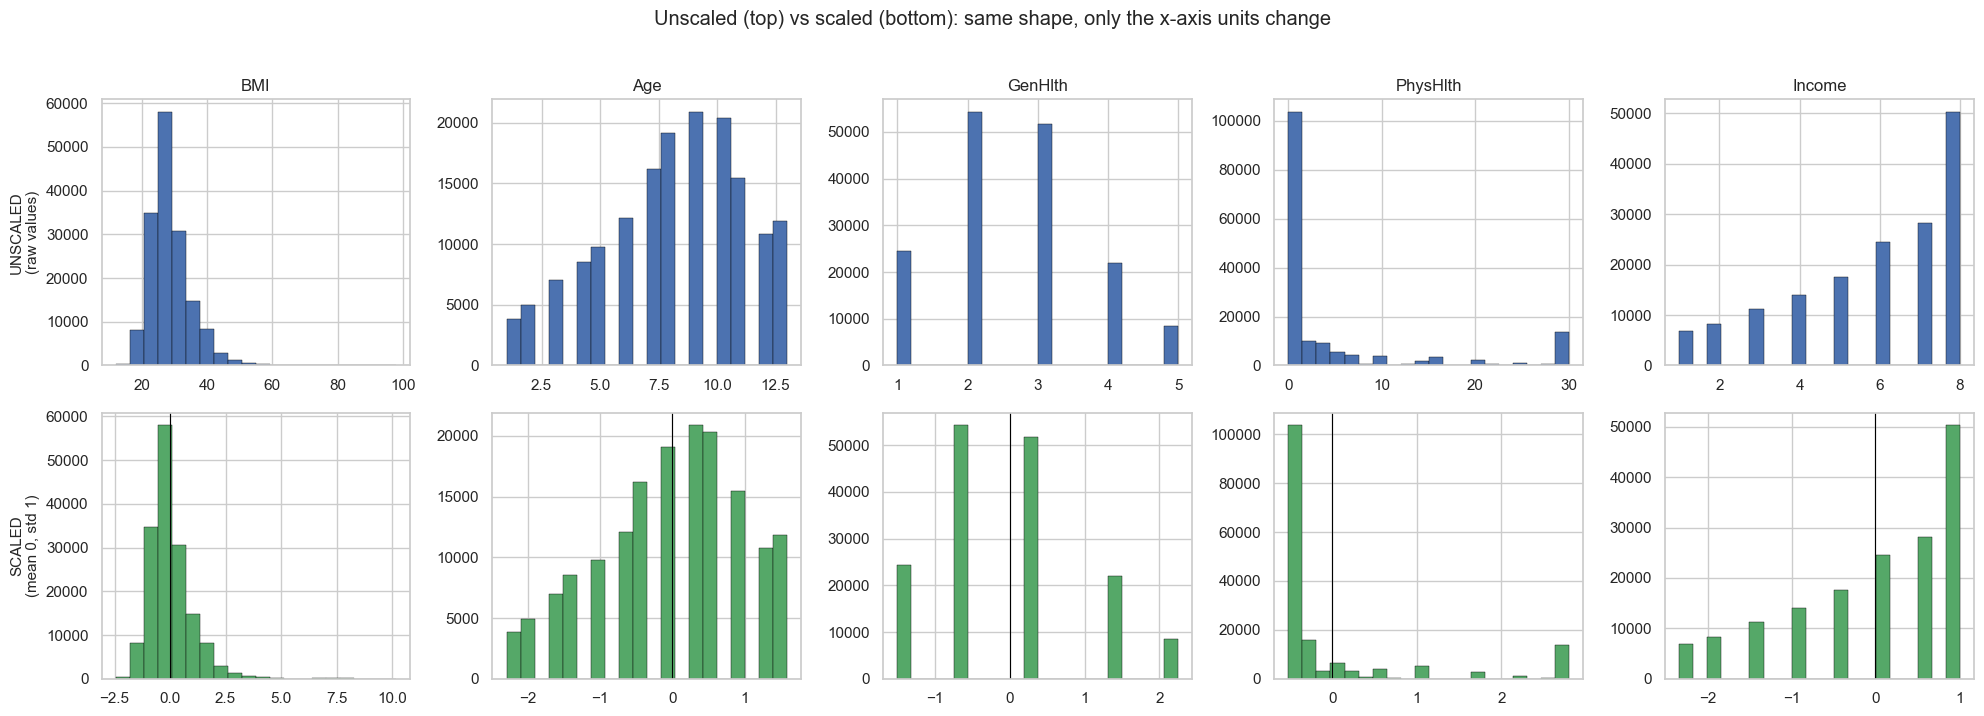

In [18]:
# Both histograms side by side: UNSCALED (top) vs SCALED (bottom) for the spread features.
# The shape of each pair is identical - only the x-axis changes to mean 0, std 1.
check = ["BMI", "Age", "GenHlth", "PhysHlth", "Income"]
fig, axes = plt.subplots(2, len(check), figsize=(4 * len(check), 7))
for j, f in enumerate(check):
    col = X.columns.get_loc(f)
    axes[0, j].hist(X_train[f], bins=20, color="#4c72b0", edgecolor="black", linewidth=0.3)
    axes[0, j].set_title(f"{f}")
    axes[1, j].hist(X_train_s[:, col], bins=20, color="#55a868", edgecolor="black", linewidth=0.3)
    axes[1, j].axvline(0, color="black", linewidth=0.8)
axes[0, 0].set_ylabel("UNSCALED\n(raw values)", fontsize=11)
axes[1, 0].set_ylabel("SCALED\n(mean 0, std 1)", fontsize=11)
plt.suptitle("Unscaled (top) vs scaled (bottom): same shape, only the x-axis units change", y=1.02)
plt.tight_layout()
plt.show()


## 10. Automatic feature selection, letting the computer choose

We use two feature-selection methods, one from each standard family: a **wrapper**
(classifier-based **forward selection**) and a **filter** (statistical **mutual information**)

**Method 1, forward selection (wrapper).** Start with no features; at each step
add the single feature that most improves the cross-validated **class-wise averaged rate**; stop
when adding more no longer helps. We use LDA as the inner classifier on
a stratified subsample for speed.

In [19]:
# subsample of the TRAINING data for a fast selection search
X_sel, _, y_sel, _ = train_test_split(X_train_s, y_train, train_size=30000,
                                      stratify=y_train, random_state=RANDOM_STATE)

# Greedy forward selection: record the class-wise rate as we force k = 1..8 features
sizes, scores = [], []
for k in [1, 2, 3, 4, 5, 6, 7, 8]:
    sfs = SequentialFeatureSelector(LinearDiscriminantAnalysis(), n_features_to_select=k,
                                    direction="forward", scoring="balanced_accuracy",
                                    cv=3, n_jobs=-1).fit(X_sel, y_sel)
    feats = X.columns[sfs.get_support()].tolist()
    s = cross_val_score(LinearDiscriminantAnalysis(), X_sel[:, sfs.get_support()], y_sel,
                        cv=3, scoring="balanced_accuracy").mean()
    sizes.append(k); scores.append(s)
    print(f"k={k}: class-wise rate = {s:.4f}   features = {feats}")

k=1: class-wise rate = 0.5663   features = ['Stroke']
k=2: class-wise rate = 0.5663   features = ['CholCheck', 'Stroke']
k=3: class-wise rate = 0.5665   features = ['CholCheck', 'Stroke', 'PhysActivity']
k=4: class-wise rate = 0.5665   features = ['CholCheck', 'Stroke', 'PhysActivity', 'Education']
k=5: class-wise rate = 0.5665   features = ['CholCheck', 'Stroke', 'PhysActivity', 'MentHlth', 'Education']
k=6: class-wise rate = 0.5666   features = ['CholCheck', 'BMI', 'Stroke', 'PhysActivity', 'MentHlth', 'Education']
k=7: class-wise rate = 0.5666   features = ['CholCheck', 'BMI', 'Stroke', 'PhysActivity', 'NoDocbcCost', 'MentHlth', 'Education']
k=8: class-wise rate = 0.5667   features = ['CholCheck', 'BMI', 'Stroke', 'PhysActivity', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'Education']


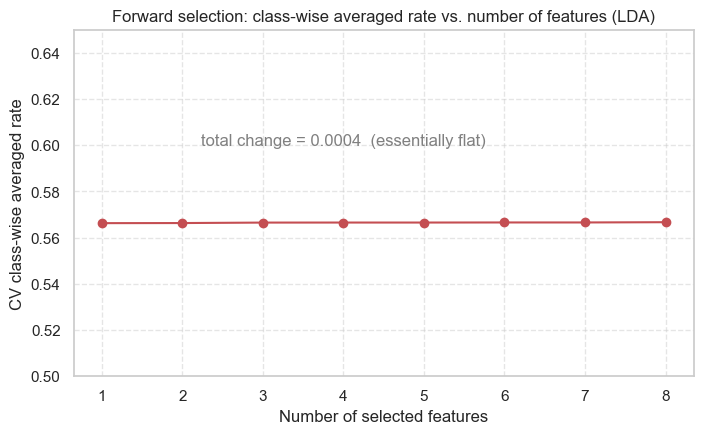

In [20]:
plt.figure(figsize=(8, 4.5))
plt.plot(sizes, scores, marker="o", color="#c44e52")
plt.title("Forward selection: class-wise averaged rate vs. number of features (LDA)")
plt.xlabel("Number of selected features"); plt.ylabel("CV class-wise averaged rate")
plt.ylim(0.5, 0.65)          # fixed scale -> shows the curve is essentially FLAT
plt.grid(linestyle="--", alpha=0.5)
# annotate the tiny total change so the auto-zoom illusion is clear
plt.text(4, 0.60, f"total change = {max(scores)-min(scores):.4f}  (essentially flat)",
         ha="center", color="gray")
plt.show()


**What the computer decided (Method 1):** the curve is **almost flat**. After the first 1 to
2 features the class-wise rate does not improve, so forward selection would **stop very early**:
LDA's class-wise rate simply cannot be pushed up by adding more features. We can see here we are facing the limitaiton thing.

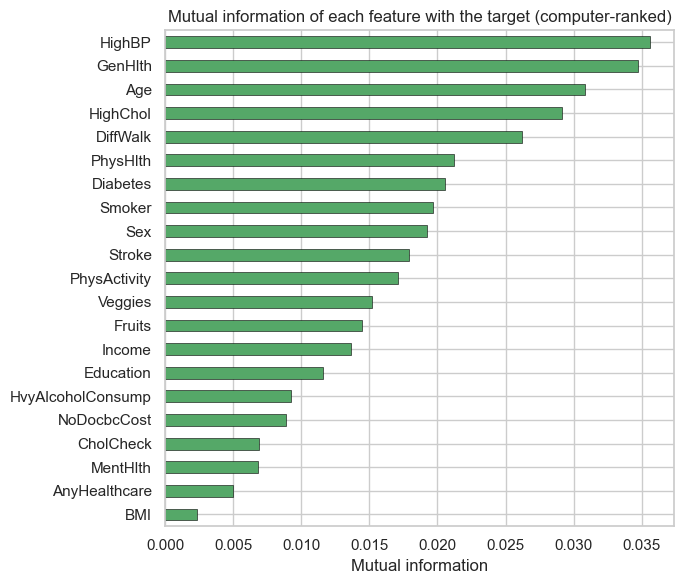

Top features the computer ranks by mutual information:
HighBP      0.0356
GenHlth     0.0347
Age         0.0308
HighChol    0.0291
DiffWalk    0.0262
PhysHlth    0.0212
Diabetes    0.0206
dtype: float64


In [21]:
# Method 2, mutual information (statistical feature selection).
# Unlike correlation it also captures non-linear dependence. Computed on TRAINING data only.
mi = pd.Series(mutual_info_classif(X_train_s, y_train, random_state=RANDOM_STATE),
               index=X.columns).sort_values()
ax = mi.plot(kind="barh", figsize=(7, 6), color="#55a868", edgecolor="black", linewidth=0.4)
ax.set_title("Mutual information of each feature with the target (computer-ranked)")
ax.set_xlabel("Mutual information")
plt.tight_layout(); plt.show()
print("Top features the computer ranks by mutual information:")
print(mi.sort_values(ascending=False).head(7).round(4))

**What the computer decided (Method 2):** mutual information ranks `GenHlth`, `Age`, `HighBP`,
`HighChol`, `DiffWalk`, `PhysHlth` and `Diabetes` highest, **agreeing with the correlation
chart**. Two independent methods pointing at the same features is strong evidence they are the
real drivers.

**Our decision:** because forward selection plateaus and we have many samples for few features
(p much smaller than n, so no curse of dimensionality), we **keep all 21 features** for the
kNN classifier, but we have now shown, with two independent methods, *which* features the computer
considers most important and *why*.

## 11. Error measures, 



**The measures we use:**

- **0-1 classification error**: $E = \frac{1}{n}\sum_i \mathbb{1}(y_i \neq \hat{y}_i)$, the
  fraction of wrong predictions (= 1 - accuracy). The basic classification measure, but misleading
  under imbalance, so we show it only for reference.
- **Sensitivity** (true-positive rate) and **Specificity** (true-negative rate): the per-class
  rates from the ROC setting.
- The **confusion matrix** shows the raw counts behind all of the above.



## 12. Handling the class imbalance

Our data is about 10:1 imbalanced, so we handle it in several standard ways.

**1. Use the right error measure.** The most important step: we score every model
with the **class-wise averaged classification rate** and read the **confusion matrix**, so the
rare "Yes" class counts as much as the common "No" class.

**2. Resampling.** kNN has no built-in class weighting, so we rebalance the data instead. We
build a new training set by **undersampling** the majority class so both classes are equal,
which stops kNN from simply following the dense "No" neighbourhood. We demonstrate this below.

**Important:** any resampling is done on the **training data only**. The test set keeps its real
10:1 ratio, otherwise the measured result would not reflect reality.

In [22]:
# Resampling demo: undersample the majority class to a balanced TRAINING set
idx_pos = np.where(y_train.values == 1)[0]
idx_neg = np.where(y_train.values == 0)[0]
rng = np.random.RandomState(RANDOM_STATE)
idx_neg_down = rng.choice(idx_neg, size=len(idx_pos), replace=False)   # as many No as Yes
bal = np.concatenate([idx_pos, idx_neg_down]); rng.shuffle(bal)
X_bal, y_bal = X_train_s[bal], y_train.values[bal]
print(f"Balanced training set: {X_bal.shape[0]:,} rows, positive share = {y_bal.mean():.0%}")

# kNN trained on the balanced data, tested on the untouched (still 10:1) test set
knn_bal = KNeighborsClassifier(n_neighbors=25).fit(X_bal, y_bal)
y_bal_pred = knn_bal.predict(X_test_s)
print("Class-wise rate:", round(balanced_accuracy_score(y_test, y_bal_pred), 3),
      "| Sensitivity:", round(recall_score(y_test, y_bal_pred, pos_label=1), 3),
      "| Specificity:", round(recall_score(y_test, y_bal_pred, pos_label=0), 3))

Balanced training set: 33,204 rows, positive share = 50%
Class-wise rate: 0.746 | Sensitivity: 0.796 | Specificity: 0.696


**What we learn:** undersampling rebalances the two classes, so kNN no longer follows only the
dense "No" neighbourhood. This **raises sensitivity** (it catches more of the rare "Yes" cases) at
some cost to specificity, compared with plain kNN on the original 10:1 data.

## 13. Choice of classifier

We use **k-Nearest-Neighbours (kNN)** as our classifier.

**Why kNN.** It is a simple, intuitive *non-parametric* baseline: it makes no assumption about
the shape of the decision boundary and predicts a point from the majority class among its *k*
closest neighbours. This makes it a natural fit for our mostly-binary health indicators, and it
gives us one clear hyperparameter to tune (*k*) by cross-validation.

## 15. Evaluation helper

One small function scores our fitted kNN with the four error measures and draws the confusion
matrix **twice, side by side**: the **absolute** one (counts) and the **relative** one
(row-normalized, so the diagonal shows the per-class rates = sensitivity and specificity).

In [23]:
def evaluate(name, y_true, y_pred, y_prob):
    """
    Evaluate a binary classification model.

    Parameters:
    -----------
    name : str
        Model name for display.
    y_true : array-like
        True labels.
    y_pred : array-like
        Predicted class labels.
    y_prob : array-like
        Predicted probabilities for the positive class.
    """

    accuracy = accuracy_score(y_true, y_pred)
    error = 1 - accuracy
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred, pos_label=1)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    roc_auc = roc_auc_score(y_true, y_prob)

    print("=" * 50)
    print(name)
    print("=" * 50)

    print(f"Accuracy             : {accuracy:.3f}")
    print(f"0-1 Error            : {error:.3f}")
    print(f"Balanced Accuracy    : {balanced_acc:.3f}")
    print(f"Sensitivity (Recall) : {sensitivity:.3f}")
    print(f"Specificity          : {specificity:.3f}")
    print(f"ROC-AUC Score        : {roc_auc:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Absolute confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=["No", "Yes"]
    ).plot(
        cmap="Blues",
        ax=axes[0],
        colorbar=False
    )
    axes[0].set_title("Absolute")

    # Normalized confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, normalize="true"),
        display_labels=["No", "Yes"]
    ).plot(
        cmap="Blues",
        ax=axes[1],
        colorbar=False,
        values_format=".2f"
    )
    axes[1].set_title("Normalized")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    axes[2].plot(fpr, tpr, linewidth=2,
                 label=f"AUC = {roc_auc:.3f}")

    axes[2].plot([0, 1], [0, 1], '--', color='gray')

    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

## 16. Base classifier, k-Nearest Neighbours

kNN has one hyperparameter, `k` (how many neighbours vote). To find the best `k` we try several
values, measure each by **cross-validation on the training data only**, plot the result, and pick
the `k` with the highest class-wise rate.

k= 3: CV class-wise rate = 0.5728
k= 5: CV class-wise rate = 0.5631
k= 9: CV class-wise rate = 0.5547
k=15: CV class-wise rate = 0.5464
k=25: CV class-wise rate = 0.5399
k=35: CV class-wise rate = 0.5349
k=45: CV class-wise rate = 0.5334


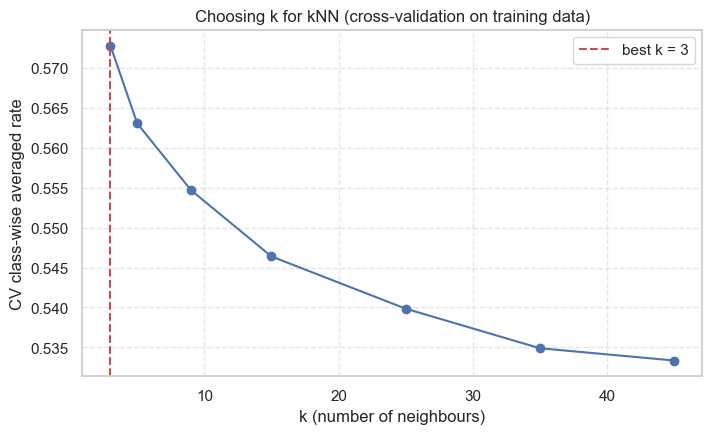

Chosen best k: 3


In [25]:
k_values = [3, 5, 9, 15, 25, 35, 45]
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_s, y_train,
                            cv=3, scoring="balanced_accuracy", n_jobs=-1).mean()
            for k in k_values]
for k, s in zip(k_values, k_scores):
    print(f"k={k:>2}: CV class-wise rate = {s:.4f}")

best_k = k_values[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4.5))
plt.plot(k_values, k_scores, marker="o", color="#4c72b0")
plt.axvline(best_k, color="#c44e52", linestyle="--", label=f"best k = {best_k}")
plt.title("Choosing k for kNN (cross-validation on training data)")
plt.xlabel("k (number of neighbours)"); plt.ylabel("CV class-wise averaged rate")
plt.legend(); plt.grid(linestyle="--", alpha=0.5)
plt.show()
print("Chosen best k:", best_k)

=== kNN (k=3) ===
CV class-wise rate (train) : 0.573


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


k-Nearest Neighbors
Accuracy             : 0.886
0-1 Error            : 0.114
Balanced Accuracy    : 0.516
Sensitivity (Recall) : 0.050
Specificity          : 0.982
ROC-AUC Score        : 0.584


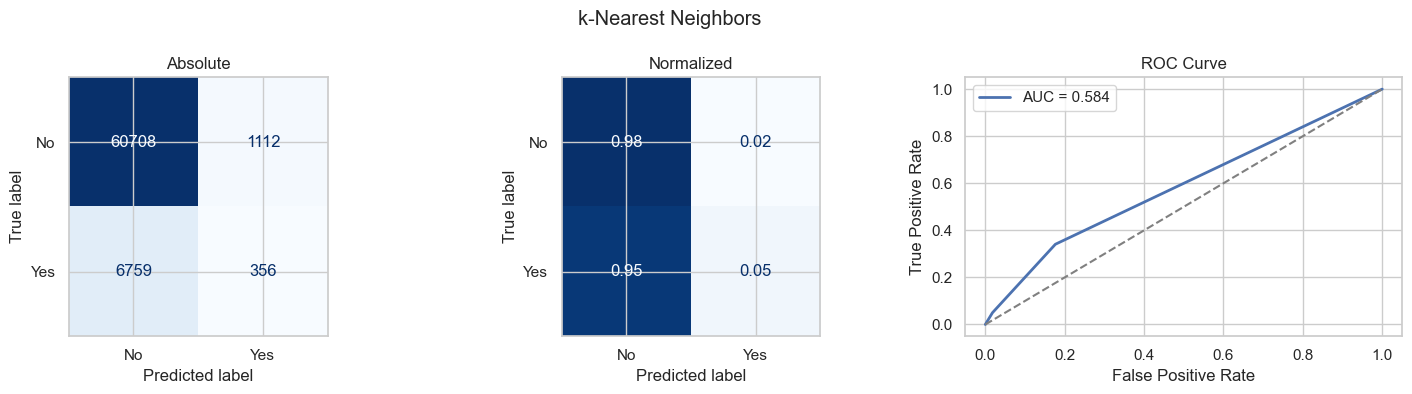

In [26]:
# Train the base model with the chosen k and evaluate on the test set
knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_s, y_train)
print(f"=== kNN (k={best_k}) ===")
print(f"CV class-wise rate (train) : {max(k_scores):.3f}")
y_pred = knn.predict(X_test)

y_prob = knn.predict_proba(X_test)[:, 1]

evaluate(
    "k-Nearest Neighbors",
    y_test,
    y_pred,
    y_prob
)

**Note:** kNN has a low 0-1 error but its confusion matrix shows it labels almost everyone
"No", giving very low **sensitivity**. Classic imbalance behaviour, and why we move to
class-weighted advanced models.

## 17. Cross-Validation of the Base kNN Classifier

The previous evaluation measured the performance of the k-Nearest Neighbors (kNN) classifier using a single train-test split. While this provides a good estimate of performance, the results may depend on the specific random split of the dataset.

To obtain a more reliable estimate of the model's generalization ability, we perform **5-Fold Cross-Validation**.

In 5-fold cross-validation:

- The dataset is divided into five equal subsets (folds).
- The model is trained on four folds and tested on the remaining fold.
- This process is repeated five times so that each fold serves as the test set once.
- The final performance is reported as the average accuracy across all five folds.

Cross-validation helps evaluate whether the model performs consistently on different subsets of the data and reduces the risk of drawing conclusions from a single train-test split.

A low standard deviation indicates that the model is stable, whereas a high standard deviation suggests that its performance varies depending on the data split.

In [27]:
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    knn,
    X_train_s,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("5-Fold Cross Validation Accuracy")
print("--------------------------------")
print("Scores:", cv_scores)
print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")

5-Fold Cross Validation Accuracy
--------------------------------
Scores: [0.87538079 0.87829898 0.87907613 0.87512823 0.87954242]

Mean Accuracy : 0.8775
Standard Deviation : 0.0019


# 18. Advanced Model 1 – Random Forest Classifier (Default Parameters)

After evaluating the baseline k-Nearest Neighbors classifier, we now investigate a more advanced machine learning algorithm: the **Random Forest Classifier**.

Random Forest was selected because it is an ensemble learning algorithm discussed during the course. It is robust against overfitting, models nonlinear relationships, and provides feature importance, making it suitable for structured medical datasets.

Compared to a single decision tree, Random Forest generally:

- Reduces overfitting
- Handles nonlinear relationships effectively
- Is robust to noisy data
- Provides better generalization performance
- Can estimate feature importance

In this first experiment, we train the Random Forest model using its **default parameters**. This serves as a baseline before applying hyperparameter optimization in the next section.

Random Forest (Default)
Accuracy             : 0.892
0-1 Error            : 0.108
Balanced Accuracy    : 0.545
Sensitivity (Recall) : 0.108
Specificity          : 0.982
ROC-AUC Score        : 0.804


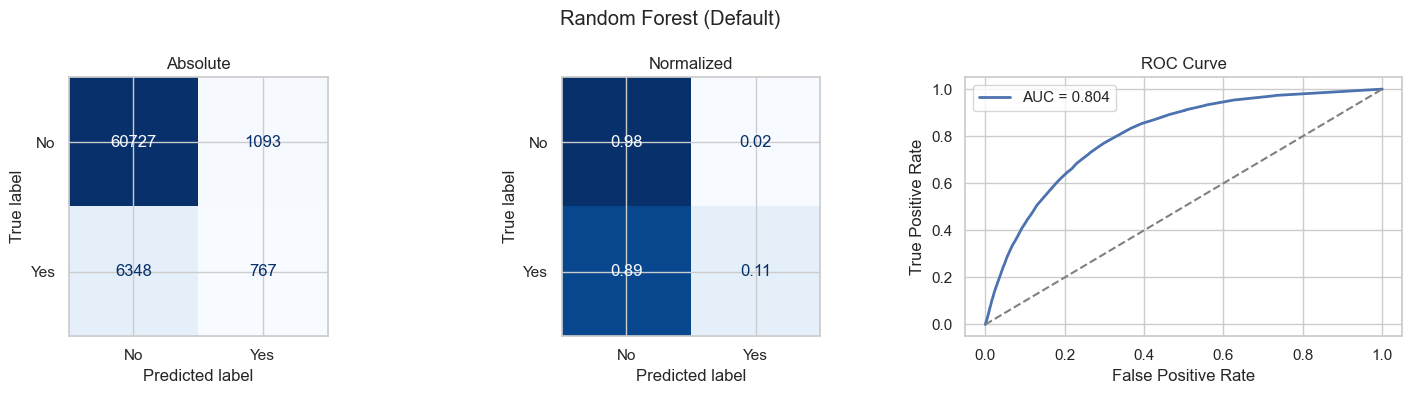

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest with default parameters
rf = RandomForestClassifier(
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Prediction probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate the model
evaluate(
    "Random Forest (Default)",
    y_test,
    y_pred_rf,
    y_prob_rf
)

# 19. Hyperparameter Optimization of the Random Forest Classifier

The default Random Forest classifier uses predefined parameter values that may not be optimal for this dataset. To improve model performance, we perform **hyperparameter optimization** using GridSearchCV.

GridSearchCV systematically evaluates multiple combinations of hyperparameters using 5-fold cross-validation and selects the configuration that achieves the best average performance.

The following hyperparameters are optimized:

- **n_estimators** – Number of decision trees in the forest.
- **max_depth** – Maximum depth of each tree.
- **min_samples_split** – Minimum number of samples required to split an internal node.
- **min_samples_leaf** – Minimum number of samples required in a leaf node.

The optimized model will then be compared with the default Random Forest classifier to determine whether hyperparameter tuning improves predictive performance.
Due to the large dataset and the computational cost of Random Forest hyperparameter tuning, a reduced parameter grid was used. The optimization was performed with 3-fold cross-validation and balanced accuracy as the scoring metric. Balanced accuracy was selected because the dataset is imbalanced and standard accuracy may overestimate performance by favoring the majority class.

In [29]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=3,
    scoring="balanced_accuracy",
    n_jobs=1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross Validation Score:")
print(f"{grid_rf.best_score_:.4f}")

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}

Best Cross Validation Score:
0.5445


Random Forest (Optimized)
Accuracy             : 0.892
0-1 Error            : 0.108
Balanced Accuracy    : 0.545
Sensitivity (Recall) : 0.108
Specificity          : 0.982
ROC-AUC Score        : 0.804


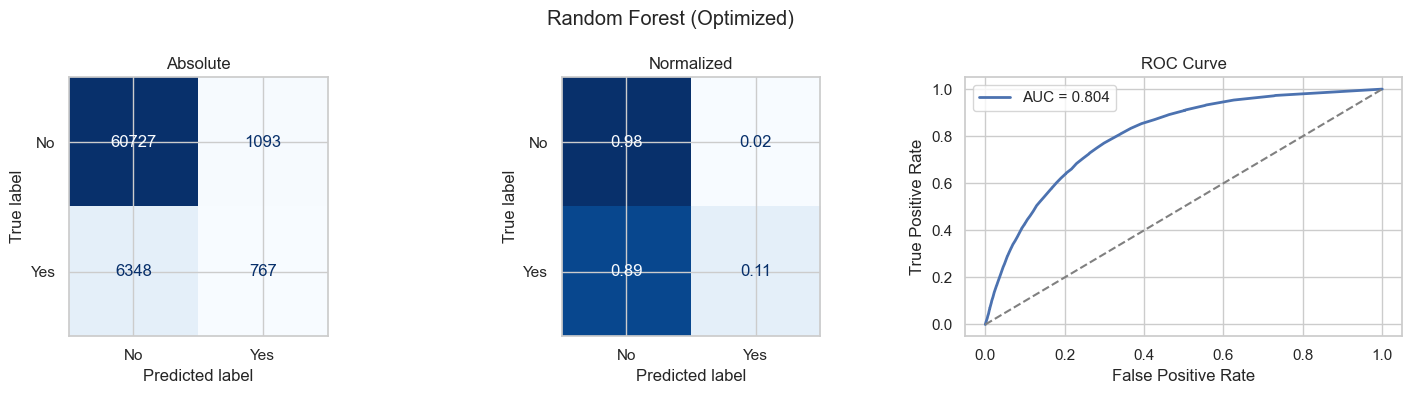

In [30]:
best_rf = grid_rf.best_estimator_

y_pred_rf_best = best_rf.predict(X_test)

y_prob_rf_best = best_rf.predict_proba(X_test)[:,1]

evaluate(
    "Random Forest (Optimized)",
    y_test,
    y_pred_rf_best,
    y_prob_rf_best
)

# 20. Random Forest using the Selected Features

In the previous experiment, the Random Forest classifier was trained using all available features.

In this experiment, the classifier is trained using only the features selected during the feature selection stage. The purpose is to investigate whether removing less informative features improves the model's predictive performance.

Reducing the number of input features may:

- reduce overfitting,
- simplify the model,
- decrease computational cost,
- improve generalization.

The optimized Random Forest parameters obtained from the previous section are reused to ensure that the comparison focuses only on the effect of feature selection.

In [31]:
print(feats)

['CholCheck', 'BMI', 'Stroke', 'PhysActivity', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth', 'Education']


Random Forest (Selected Features)
Accuracy             : 0.892
0-1 Error            : 0.108
Balanced Accuracy    : 0.520
Sensitivity (Recall) : 0.052
Specificity          : 0.988
ROC-AUC Score        : 0.622


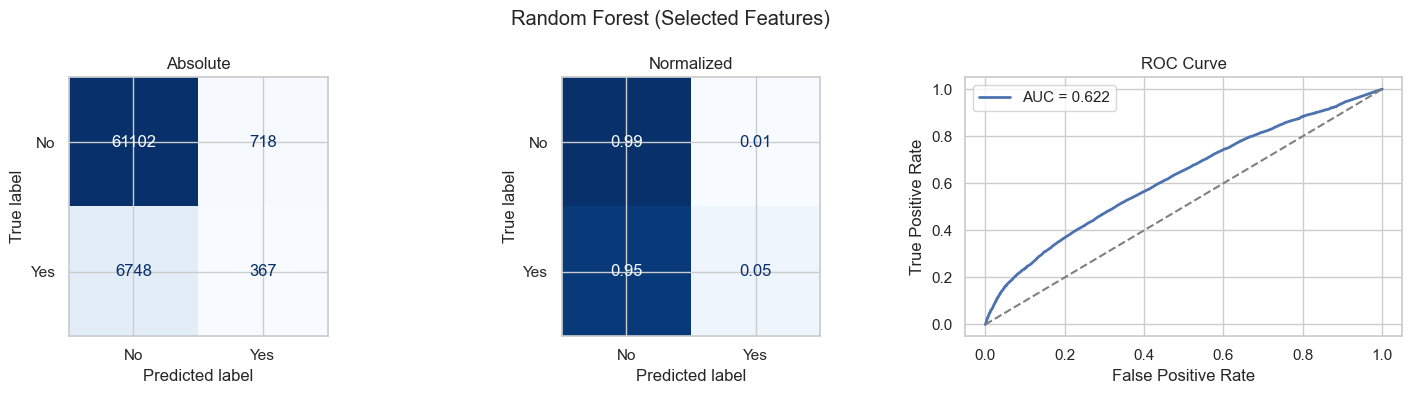

In [32]:
selected_features = feats

X_train_rf_sel = X_train[selected_features]
X_test_rf_sel = X_test[selected_features]

rf_selected = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=grid_rf.best_params_["n_estimators"],
    max_depth=grid_rf.best_params_["max_depth"],
    max_features=grid_rf.best_params_["max_features"]
)

rf_selected.fit(X_train_rf_sel, y_train)

y_pred_rf_sel = rf_selected.predict(X_test_rf_sel)
y_prob_rf_sel = rf_selected.predict_proba(X_test_rf_sel)[:, 1]

evaluate(
    "Random Forest (Selected Features)",
    y_test,
    y_pred_rf_sel,
    y_prob_rf_sel
)

## Result Analysis

The Random Forest classifier was evaluated using both the complete feature set and the reduced feature set obtained from Sequential Forward Selection.

### Comparison of Results

| Metric | All Features | Selected Features |
|---------|-------------:|------------------:|
| Accuracy | 0.892 | 0.892 |
| Balanced Accuracy | 0.545 | 0.520 |
| Sensitivity | 0.108 | 0.052 |
| Specificity | 0.982 | 0.988 |
| ROC-AUC | 0.804 | 0.622 |

### Discussion

The overall accuracy remained unchanged at **89.2%** for both experiments. However, because the dataset is imbalanced, accuracy alone does not provide a complete picture of the classifier's performance.

The Random Forest model trained with **all features** achieved a higher **Balanced Accuracy (0.545)** than the model trained using only the selected features (0.520). This indicates that the classifier performed better overall when all available features were included.

The most noticeable difference was observed in **Sensitivity**, which decreased from **0.108** to **0.052** after feature selection. This means that the classifier detected fewer positive heart disease cases when only the selected features were used.

Although **Specificity** increased slightly (from **0.982** to **0.988**), this improvement came at the cost of correctly identifying fewer patients with heart disease.

The **ROC-AUC** score also decreased considerably, from **0.804** to **0.622**, indicating that the classifier's ability to distinguish between the two classes became weaker after reducing the feature set.

### Conclusion

For this dataset, the Random Forest classifier achieved better overall performance when trained using **all available features**. The selected feature subset simplified the model but removed information that was useful for classification. Therefore, the complete feature set was retained as the preferred feature representation for the Random Forest classifier.

# 21. Advanced Model 2 – Support Vector Machine (Default Parameters)

The second advanced classifier evaluated in this project is the **Support Vector Machine (SVM)**.

Unlike kNN, which classifies a sample based on its nearest neighbours, the SVM attempts to find an optimal decision boundary (hyperplane) that maximizes the separation between the two classes.

One of the main advantages of SVM is its ability to produce strong classification performance, especially for high-dimensional datasets. Furthermore, by using kernel functions, SVM can model both linear and non-linear decision boundaries.

In this first experiment, the classifier is trained using the default parameters provided by Scikit-Learn. The performance of this default model will later be compared with an optimized SVM obtained through hyperparameter optimization.

The Support Vector Machine (SVM) constructs a separating hyperplane that maximizes the margin between the two classes. For this dataset, a Linear SVM was used because it is computationally more efficient for large datasets while following the same classification principle presented in the lecture.



Linear SVM (Default)
Accuracy             : 0.899
0-1 Error            : 0.101
Balanced Accuracy    : 0.523
Sensitivity (Recall) : 0.050
Specificity          : 0.996
ROC-AUC Score        : 0.836


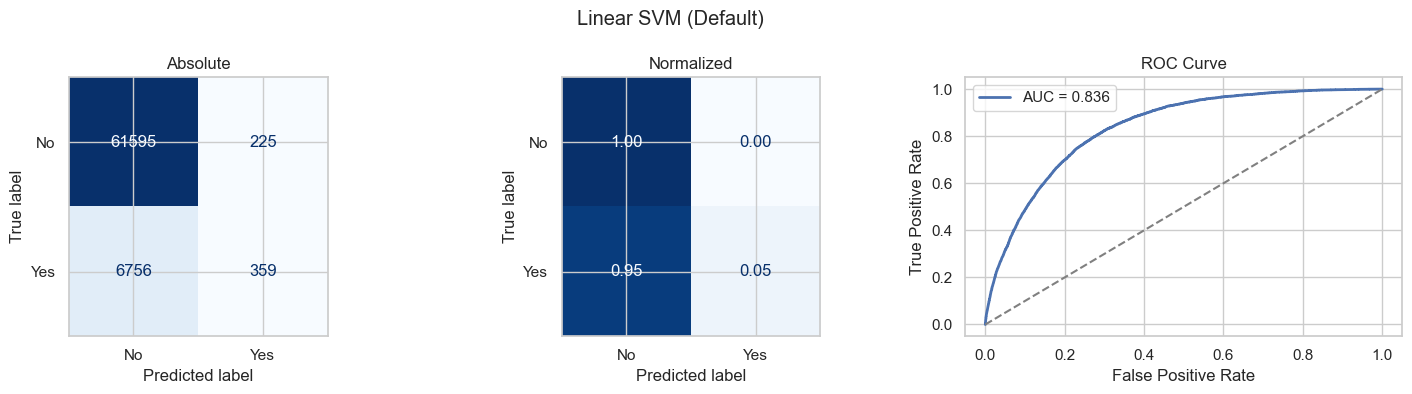

In [35]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1,
    random_state=42,
    max_iter=5000
)

svm.fit(X_train_s, y_train)

y_pred_svm = svm.predict(X_test_s)

# Distance to the separating hyperplane
y_score_svm = svm.decision_function(X_test_s)

evaluate(
    "Linear SVM (Default)",
    y_test,
    y_pred_svm,
    y_score_svm
)

## Result Analysis

The Linear SVM classifier achieved the highest overall accuracy (89.9%) among the models evaluated so far. It also produced the lowest classification error and the highest ROC-AUC score (0.836), indicating good separation between the two classes.

However, the Balanced Accuracy (0.523) and Sensitivity (0.050) remained relatively low. This indicates that although the classifier correctly identified almost all healthy patients (Specificity = 0.996), it detected only a small proportion of patients with heart disease.

Compared to the Random Forest classifier, the SVM achieved higher Accuracy and ROC-AUC but lower Balanced Accuracy and Sensitivity.

This demonstrates that different evaluation metrics emphasize different aspects of classifier performance. For imbalanced medical datasets, relying solely on overall Accuracy may lead to misleading conclusions. Therefore, Balanced Accuracy, Sensitivity, Specificity and ROC-AUC should all be considered when evaluating the classifier.

# 22. Hyperparameter Optimization of the Linear SVM

The default Linear SVM uses a regularization parameter \(C = 1\). The value of \(C\) controls the trade-off between maximizing the margin and minimizing classification errors.

A small value of \(C\) allows a wider margin with more classification errors, while a large value of \(C\) attempts to classify all training samples correctly but may increase the risk of overfitting.

To determine the most suitable value, GridSearchCV is used with 5-fold cross-validation. The classifier is evaluated using Balanced Accuracy because the dataset is imbalanced.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_svm = GridSearchCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=5000
    ),
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=1
)

grid_svm.fit(X_train_s, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest Cross Validation Score:")
print(f"{grid_svm.best_score_:.4f}")

Best Parameters:
{'C': 1}

Best Cross Validation Score:
0.5245


## Hyperparameter Optimization Analysis

GridSearchCV was used to determine the optimal value of the regularization parameter **C** for the Linear SVM classifier.

The search evaluated the following values:

- C = 0.01
- C = 0.1
- C = 1
- C = 10
- C = 100

The best-performing model was obtained with:

- **C = 1**

which is also the default value used by the classifier.

The best cross-validation Balanced Accuracy was **0.5245**, indicating that changing the regularization strength did not improve the model performance for this dataset.

This suggests that the default Linear SVM configuration already provides the best trade-off between model complexity and classification performance within the tested parameter range.

Linear SVM (Optimized)
Accuracy             : 0.899
0-1 Error            : 0.101
Balanced Accuracy    : 0.523
Sensitivity (Recall) : 0.050
Specificity          : 0.996
ROC-AUC Score        : 0.836


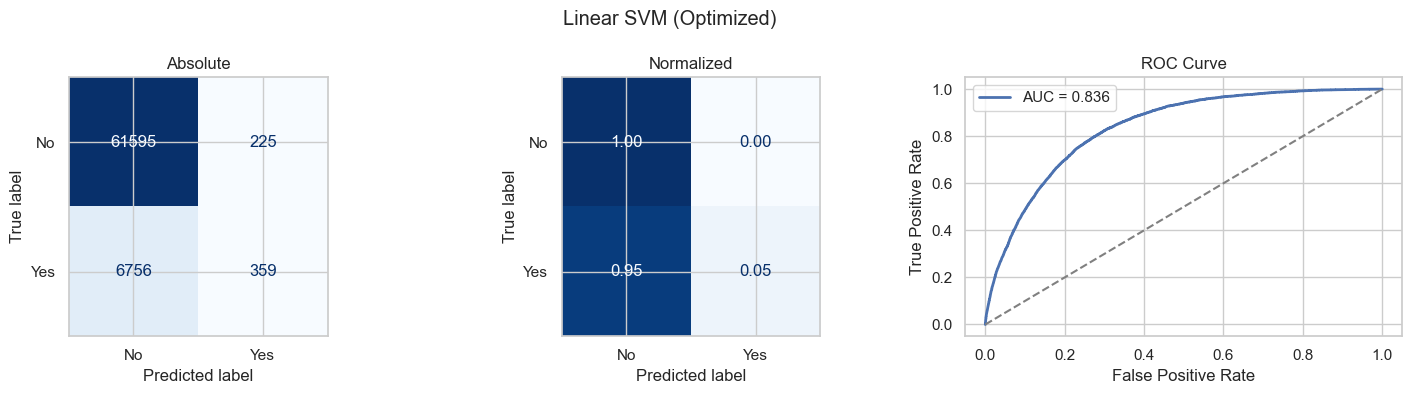

In [37]:
best_svm = grid_svm.best_estimator_

y_pred_svm_best = best_svm.predict(X_test_s)

# LinearSVC provides the distance to the hyperplane
y_score_svm_best = best_svm.decision_function(X_test_s)

evaluate(
    "Linear SVM (Optimized)",
    y_test,
    y_pred_svm_best,
    y_score_svm_best
)

## Result Analysis

The optimized Linear SVM classifier produced identical results to the default model.

This outcome is expected because GridSearchCV identified the default regularization parameter (**C = 1**) as the best-performing configuration.

Consequently, no improvement was observed after hyperparameter optimization.

This indicates that, for the evaluated parameter range, the default Linear SVM already provides the best trade-off between margin maximization and classification performance on this dataset.

This experiment also demonstrates that hyperparameter optimization does not always improve a classifier. Instead, it confirms whether the default configuration is already suitable for the given prediction task.

# 23. Linear SVM using the Selected Features

The final experiment evaluates the Linear SVM classifier using only the features selected during the feature selection stage.

The objective is to determine whether reducing the feature set improves or degrades the classifier's predictive performance.

The optimized Linear SVM configuration obtained in the previous section is reused to ensure that the comparison focuses solely on the effect of feature selection.

Linear SVM (Selected Features)
Accuracy             : 0.897
0-1 Error            : 0.103
Balanced Accuracy    : 0.500
Sensitivity (Recall) : 0.001
Specificity          : 1.000
ROC-AUC Score        : 0.651


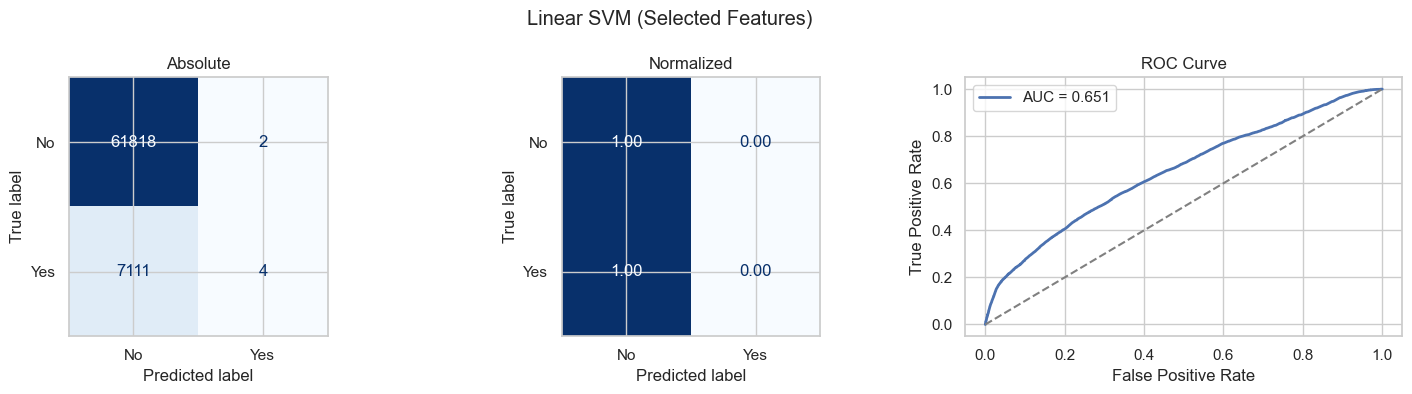

In [38]:
selected_features = feats

# Select only the chosen features
X_train_s_sel = X_train_s[:, sfs.get_support()]
X_test_s_sel = X_test_s[:, sfs.get_support()]

# Train optimized Linear SVM
svm_selected = LinearSVC(
    C=grid_svm.best_params_["C"],
    random_state=42,
    max_iter=5000
)

svm_selected.fit(X_train_s_sel, y_train)

# Predictions
y_pred_svm_sel = svm_selected.predict(X_test_s_sel)

# Distance to separating hyperplane
y_score_svm_sel = svm_selected.decision_function(X_test_s_sel)

# Evaluate
evaluate(
    "Linear SVM (Selected Features)",
    y_test,
    y_pred_svm_sel,
    y_score_svm_sel
)

## Result Analysis

The Linear SVM classifier trained on the selected feature subset achieved a similar overall accuracy (89.7%) to the model trained on all features. However, the remaining evaluation metrics indicate that the reduced feature set significantly degraded the classifier performance.

The Balanced Accuracy decreased to **0.500**, while the Sensitivity dropped to **0.001**, meaning that the classifier correctly identified almost none of the patients with heart disease.

Although the Specificity reached **1.000**, this result indicates that the classifier almost always predicted the majority class (healthy patients), leading to very poor detection of positive cases.

The ROC-AUC score also decreased substantially from **0.836** to **0.651**, confirming that reducing the feature set weakened the classifier's ability to distinguish between the two classes.

### Conclusion

For the Linear SVM classifier, the selected feature subset resulted in a significant loss of predictive performance. Therefore, the complete feature set provides a more suitable representation for this dataset.

# 24. Overall Model Comparison

After evaluating the baseline classifier and the two advanced classifiers, the results are summarized in the following table.

The comparison includes:

- Base classifier (kNN)
- Advanced classifier 1 (Random Forest)
- Advanced classifier 2 (Linear SVM)
- Hyperparameter optimization
- Feature selection experiments

The objective is to determine which combination of classifier, hyperparameters, and feature set provides the best performance for predicting heart disease.

In [40]:
import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "kNN",
        "Random Forest (Default)",
        "Random Forest (Optimized)",
        "Random Forest (Selected Features)",
        "Linear SVM (Default)",
        "Linear SVM (Optimized)",
        "Linear SVM (Selected Features)"
    ],

    "Feature Set": [
        "All Features",
        "All Features",
        "All Features",
        "Selected Features",
        "All Features",
        "All Features",
        "Selected Features"
    ],

    "Accuracy": [
       
        0.886,
        0.892,
        0.892,
        0.892,
        0.899,
        0.899,
        0.897
    ],

    "Balanced Accuracy": [
        0.516,
        0.545,
        0.545,
        0.520,
        0.523,
        0.523,
        0.500
    ],

    "Sensitivity": [
        0.050,
        0.108,
        0.108,
        0.052,
        0.050,
        0.050,
        0.001
    ],

    "Specificity": [
        0.982,
        0.982,
        0.982,
        0.988,
        0.996,
        0.996,
        1.000
    ],

    "ROC-AUC": [
        0.584,
        0.804,
        0.804,
        0.622,
        0.836,
        0.836,
        0.651
    ]

})

comparison

,Model,Feature Set,Accuracy,Balanced Accuracy,Sensitivity,Specificity,ROC-AUC
0,kNN,All Features,0.886,0.516,0.050,0.982,0.584
1,Random Forest (Default),All Features,0.892,0.545,0.108,0.982,0.804
2,Random Forest (Optimized),All Features,0.892,0.545,0.108,0.982,0.804
3,Random Forest (Selected Features),Selected Features,0.892,0.520,0.052,0.988,0.622
4,Linear SVM (Default),All Features,0.899,0.523,0.050,0.996,0.836
5,Linear SVM (Optimized),All Features,0.899,0.523,0.050,0.996,0.836
6,Linear SVM (Selected Features),Selected Features,0.897,0.500,0.001,1.000,0.651


## Overall Discussion

Several observations can be made from the comparison of all evaluated classifiers.

### Hyperparameter Optimization

For both Random Forest and Linear SVM, hyperparameter optimization did not improve the classification performance. In both cases, GridSearchCV selected the default parameter values as the optimal configuration for the evaluated search space.

This demonstrates that hyperparameter optimization is not guaranteed to improve a model. Instead, it identifies the best parameter configuration among the tested combinations.

### Effect of Feature Selection

Feature selection reduced the number of input variables from the original dataset to eight selected features.

However, for both Random Forest and Linear SVM, the reduced feature set resulted in lower Balanced Accuracy, lower Sensitivity and lower ROC-AUC.

These results indicate that the removed features still contained useful information for predicting heart disease.

Therefore, the complete feature set produced better overall classification performance for this dataset.

### Model Comparison

The Random Forest classifier achieved the highest Balanced Accuracy and Sensitivity among the evaluated advanced classifiers, making it more suitable for detecting patients with heart disease.

The Linear SVM achieved the highest overall Accuracy and ROC-AUC but showed lower Sensitivity, indicating that it classified healthy patients very well while failing to detect many positive cases.

Since heart disease prediction is a medical classification problem, Balanced Accuracy and Sensitivity are considered more informative than overall Accuracy because correctly identifying positive patients is particularly important.

# 25. Conclusion

This project performed a scientifically grounded evaluation of several machine learning classifiers for predicting heart disease using the BRFSS dataset.

Three classifiers were evaluated:

- k-Nearest Neighbors (Baseline)
- Random Forest
- Linear Support Vector Machine

For the advanced classifiers, hyperparameter optimization was performed using GridSearchCV, followed by an additional comparison between models trained using all available features and models trained using a reduced feature set obtained through Sequential Forward Selection.

The experimental results showed that:

- Hyperparameter optimization did not improve either the Random Forest or the Linear SVM classifier because the default parameter values already produced the best cross-validation performance.
- Feature selection reduced the predictive performance of both advanced classifiers, indicating that the complete feature set contained valuable information for heart disease prediction.
- The Linear SVM achieved the highest overall Accuracy (89.9%) and ROC-AUC (0.836).
- The Random Forest classifier achieved the highest Balanced Accuracy (0.545) and Sensitivity (0.108), making it more suitable for identifying patients with heart disease.

Overall, the experiments demonstrate that classifier performance depends strongly on the selected evaluation metric.

The Linear SVM achieved the highest overall Accuracy (89.9%) and the highest ROC-AUC (0.836), indicating strong overall classification and class separation. However, it achieved a relatively low Sensitivity, meaning that many patients with heart disease were not correctly identified.

The Random Forest classifier achieved the highest Balanced Accuracy (0.545) and the highest Sensitivity (0.108), indicating better performance in detecting positive heart disease cases.

Since this is a medical classification problem where identifying patients with heart disease is particularly important, Balanced Accuracy and Sensitivity were considered more relevant than Accuracy alone.

Therefore, the Random Forest classifier trained on the complete feature set is considered the preferred model for this dataset.